# On-the-fly spectrum synthesis for validation

Generate a single Turbospectrum spectrum from Python and get back numpy arrays — useful for:
- spot-checking pipeline output against a fresh synthesis
- exploring how flux changes with one parameter
- checking limb-darkening / per-mu intensities
- comparing LTE vs NLTE for a target line

**Prerequisites** (one-time setup):
1. Build the Fortran binaries: `cd exec-gf && make all`
2. Pull Git LFS data files: `git lfs pull` (Anstee, ATOM/atom.fe607a, etc.)
3. Download atmospheres + linelists: `./scripts/download_data.sh --atmospheres MARCS --linelists`
4. Optional (NLTE): `./scripts/download_data.sh --nlte-atoms all`

If those exist under their default locations (`input_files/...`) the API picks them up automatically. Otherwise pass explicit paths via the `model_atmosphere_path` / `linelist_path` / `linelist_files` arguments.

In [14]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
if os.path.join(PROJECT_ROOT, 'scripts') not in sys.path:
    sys.path.insert(0, os.path.join(PROJECT_ROOT, 'scripts'))

import numpy as np
import matplotlib.pyplot as plt

from spectrum_api import synthesize_spectrum

# Local paths — adjust if your data lives elsewhere.
LINELIST = os.path.join(PROJECT_ROOT, 'input_files/linelists/nlte_ges_linelist_jmg16jan2026_I_II')
ATMOSPHERES = os.path.join(PROJECT_ROOT, 'input_files/model_atmospheres/1D/marcs_standard_comp/marcs_standard_comp')

DEFAULTS = dict(
    linelist_files=[LINELIST],
    model_atmosphere_path=ATMOSPHERES,
)

## 1. A single solar-like LTE spectrum (Flux mode)

`output_mode='Flux'` is the disk-integrated flux. `flux_normalized` is column 1 of the .spec file (continuum-normalized) and `flux` is column 2 (absolute, erg/s/cm²/Å). Both are 1D — shape `(n_wavelength,)`.

In [15]:
result = synthesize_spectrum(
    teff=5777,
    logg=4.4,
    feh=0.0,
    vmicro=1.0,
    lambda_min=4000.0,
    lambda_max=8000.0,
    lambda_step=0.02,
    **DEFAULTS,
)

print(f'{result.n_points} wavelength points')
print(f'flux range:        {result.flux.min():.3e} .. {result.flux.max():.3e}')
print(f'normalized range:  {result.flux_normalized.min():.3f} .. {result.flux_normalized.max():.3f}')


--- Turbospectrum Configuration ---
project_root: /Users/mjablons/code/turbo
compiler: gf
nlte: False
nlte_info_file: 
force: True
model_atmosphere_path: /Users/mjablons/code/turbo/input_files/model_atmospheres/1D/marcs_standard_comp/marcs_standard_comp
linelist_path: /Users/mjablons/code/turbo/input_files/linelists
linelist_files: ['/Users/mjablons/code/turbo/input_files/linelists/nlte_ges_linelist_jmg16jan2026_I_II']
output_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_3dn12q_1/spectra
log_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_3dn12q_1/logs
tmp_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_3dn12q_1/tmp
babsma_exec: babsma_lu
bsyn_exec: bsyn_lu
interpol_exec: interpol_modeles
babsma_path: /Users/mjablons/code/turbo/exec-gf/babsma_lu
bsyn_path: /Users/mjablons/code/turbo/exec-gf/bsyn_lu
interpol_path: /Users/mjablons/code/turbo/interpolator/interpol_modeles
output_mode: Flux
mu_angles: []
mu_points_file: 
mu_sampling: {}
la

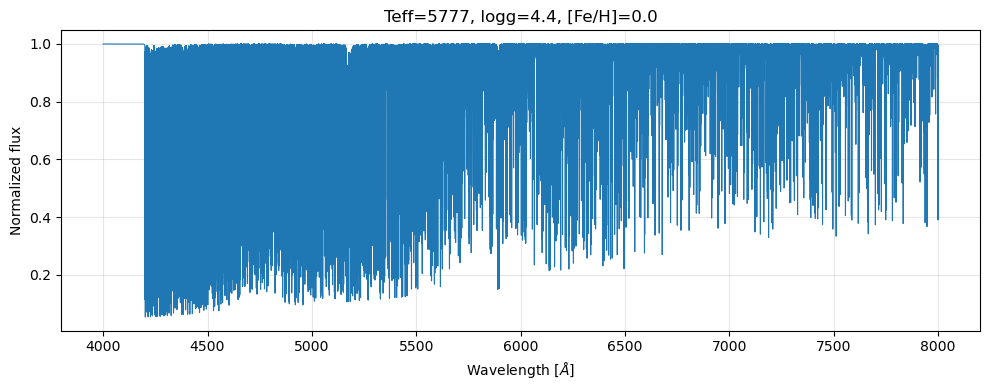

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result.wavelength, result.flux_normalized, lw=0.8)
ax.set_xlabel(r'Wavelength [$\AA$]')
ax.set_ylabel('Normalized flux')
ax.set_title(f'Teff={result.params.get("teff")}, logg={result.params.get("logg")}, [Fe/H]={result.params.get("feh")}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

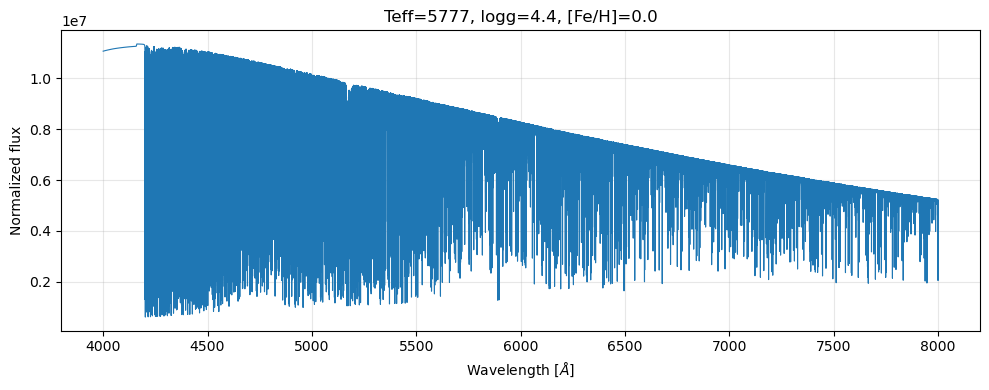

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(result.wavelength, result.flux, lw=0.8)
ax.set_xlabel(r'Wavelength [$\AA$]')
ax.set_ylabel('Normalized flux')
ax.set_title(f'Teff={result.params.get("teff")}, logg={result.params.get("logg")}, [Fe/H]={result.params.get("feh")}')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
import pickle

data_to_save = {
    "wavelength": result.wavelength,
    "flux": result.flux,
    "continuum": result.continuum if hasattr(result, "continuum") else None,
}

with open("single_spectrum.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

## 2. Per-mu intensities (Intensity mode)

`output_mode='Intensity'` adds two 2D arrays of shape `(n_mu, n_wavelength)`:
- `intensity` — absolute specific intensity at each mu, erg/s/cm²/sr/Å
- `intensity_normalized` — continuum-normalized at each mu (in [0, 1])

And `mu_angles` is the matching 1D array of mu values, ordered limb→center.

Default (`mu_angles=None`) gives the 12 Gauss-Radau mu points bsyn ships with. Pass `mu_angles=[...]` (any 1–30 values in [0, 1]) and bsyn computes intensities at exactly those mus via its `MU-POINTS:` directive — no nearest-neighbor surprises.

In [19]:
ires = synthesize_spectrum(
    teff=5777, logg=4.4, feh=0.0, vmicro=1.0,
    lambda_min=6700.0, lambda_max=6720.0, lambda_step=0.02,
    output_mode='Intensity',
    **DEFAULTS,
)

print(f'mus ({ires.n_mu}):', np.round(ires.mu_angles, 3))
print('intensity shape           :', ires.intensity.shape)
print('intensity_normalized shape:', ires.intensity_normalized.shape)
print('I_norm range:', f'{ires.intensity_normalized.min():.3f} .. {ires.intensity_normalized.max():.3f}')
assert (ires.mu_angles >= 0.0).all() and (ires.mu_angles <= 1.0).all(), 'mu out of [0,1]'


--- Turbospectrum Configuration ---
project_root: /Users/mjablons/code/turbo
compiler: gf
nlte: False
nlte_info_file: 
force: True
model_atmosphere_path: /Users/mjablons/code/turbo/input_files/model_atmospheres/1D/marcs_standard_comp/marcs_standard_comp
linelist_path: /Users/mjablons/code/turbo/input_files/linelists
linelist_files: ['/Users/mjablons/code/turbo/input_files/linelists/nlte_ges_linelist_jmg16jan2026_I_II']
output_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_2qhv1766/spectra
log_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_2qhv1766/logs
tmp_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_2qhv1766/tmp
babsma_exec: babsma_lu
bsyn_exec: bsyn_lu
interpol_exec: interpol_modeles
babsma_path: /Users/mjablons/code/turbo/exec-gf/babsma_lu
bsyn_path: /Users/mjablons/code/turbo/exec-gf/bsyn_lu
interpol_path: /Users/mjablons/code/turbo/interpolator/interpol_modeles
output_mode: Intensity
mu_angles: []
mu_points_file: 
mu_sampling: 

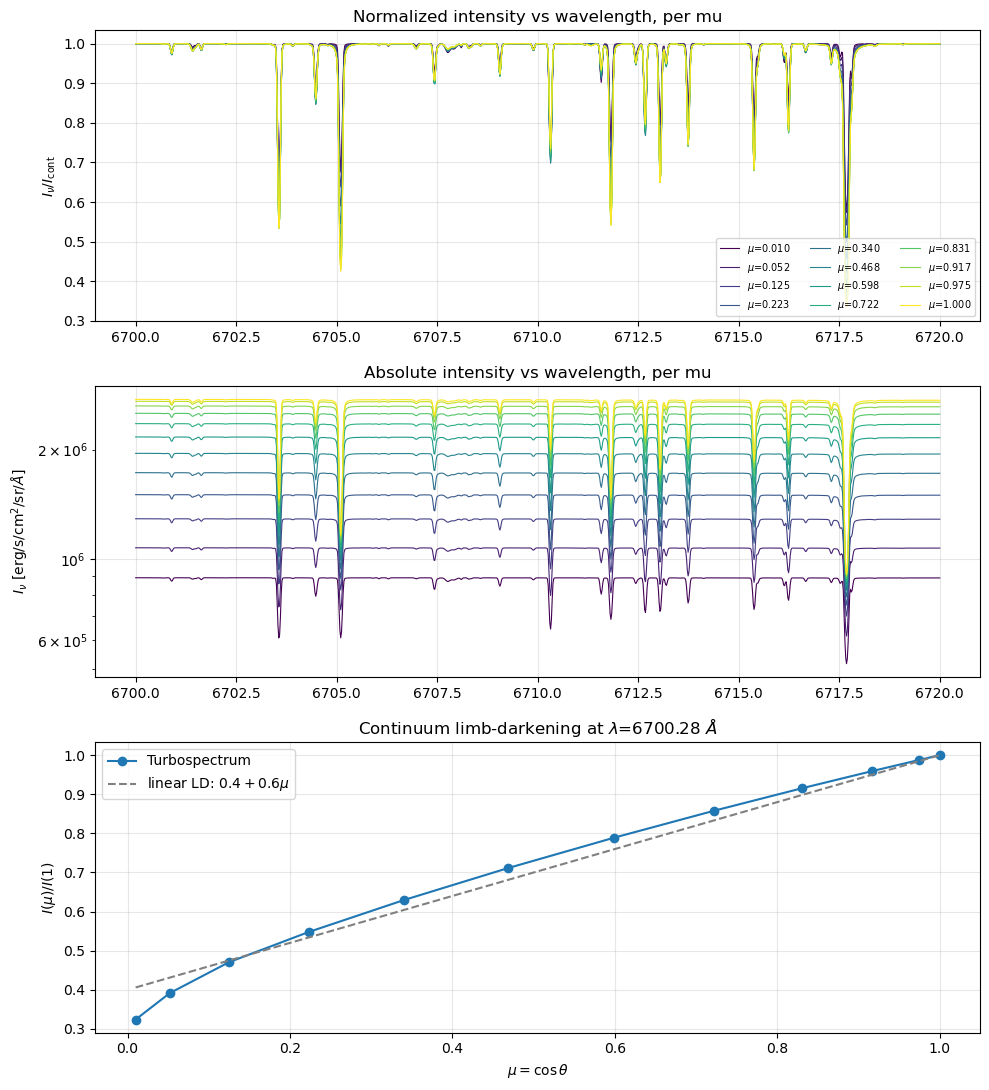

In [20]:
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0, 1, ires.n_mu))

fig, axes = plt.subplots(3, 1, figsize=(10, 11))

# (a) Normalized intensity — line shapes per mu
for i, mu in enumerate(ires.mu_angles):
    axes[0].plot(ires.wavelength, ires.intensity_normalized[i], lw=0.8,
                 color=colors[i], label=fr'$\mu$={mu:.3f}')
axes[0].set_ylabel(r'$I_\nu / I_{\rm cont}$')
axes[0].set_title('Normalized intensity vs wavelength, per mu')
axes[0].legend(ncol=3, fontsize=7, loc='lower right')
axes[0].grid(alpha=0.3)

# (b) Absolute intensity (log) — limb darkening of the continuum
for i, mu in enumerate(ires.mu_angles):
    axes[1].plot(ires.wavelength, ires.intensity[i], lw=0.8, color=colors[i])
axes[1].set_ylabel(r'$I_\nu$ [erg/s/cm$^2$/sr/$\AA$]')
axes[1].set_yscale('log')
axes[1].set_title('Absolute intensity vs wavelength, per mu')
axes[1].grid(alpha=0.3)

# (c) Continuum limb-darkening curve
idx_clean = int(np.argmax(ires.intensity_normalized[-1]))   # cleanest continuum point
I_at_mu = ires.intensity[:, idx_clean]
axes[2].plot(ires.mu_angles, I_at_mu / I_at_mu.max(), 'o-', label='Turbospectrum')
axes[2].plot(ires.mu_angles, 0.4 + 0.6 * ires.mu_angles, '--', color='gray',
             label=r'linear LD: $0.4 + 0.6\mu$')
axes[2].set_xlabel(r'$\mu = \cos\theta$')
axes[2].set_ylabel(r'$I(\mu) / I(1)$')
axes[2].set_title(fr'Continuum limb-darkening at $\lambda$={ires.wavelength[idx_clean]:.2f} $\AA$')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Custom mu set

Pass any 1–30 values in [0, 1] and bsyn computes intensities at exactly those mus:


--- Turbospectrum Configuration ---
project_root: /Users/mjablons/code/turbo
compiler: gf
nlte: False
nlte_info_file: 
force: True
model_atmosphere_path: /Users/mjablons/code/turbo/input_files/model_atmospheres/1D/marcs_standard_comp/marcs_standard_comp
linelist_path: /Users/mjablons/code/turbo/input_files/linelists
linelist_files: ['/Users/mjablons/code/turbo/input_files/linelists/nlte_ges_linelist_jmg16jan2026_I_II']
output_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_zeth4nd8/spectra
log_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_zeth4nd8/logs
tmp_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_zeth4nd8/tmp
babsma_exec: babsma_lu
bsyn_exec: bsyn_lu
interpol_exec: interpol_modeles
babsma_path: /Users/mjablons/code/turbo/exec-gf/babsma_lu
bsyn_path: /Users/mjablons/code/turbo/exec-gf/bsyn_lu
interpol_path: /Users/mjablons/code/turbo/interpolator/interpol_modeles
output_mode: Intensity
mu_angles: [0.001]
mu_points_file: /var/fold

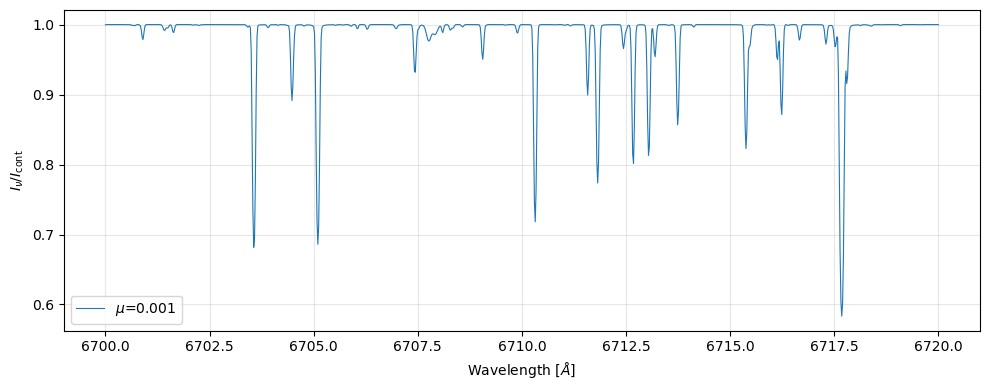

In [21]:
ires3 = synthesize_spectrum(
    teff=5777, logg=4.4, feh=0.0, vmicro=1.0,
    lambda_min=6700.0, lambda_max=6720.0, lambda_step=0.02,
    output_mode='Intensity', mu_angles=[0.001],
    **DEFAULTS,
)
print('selected mus:', np.round(ires3.mu_angles, 3))

fig, ax = plt.subplots(figsize=(10, 4))
for i, mu in enumerate(ires3.mu_angles):
    ax.plot(ires3.wavelength, ires3.intensity_normalized[i], lw=0.8, label=fr'$\mu$={mu:.3f}')
ax.set_xlabel(r'Wavelength [$\AA$]')
ax.set_ylabel(r'$I_\nu / I_{\rm cont}$')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
ires3.mu_angles

array([0.001])

## 3. Parameter sweep: same window, different Teff


--- Turbospectrum Configuration ---
project_root: /Users/mjablons/code/turbo
compiler: gf
nlte: False
nlte_info_file: 
force: True
model_atmosphere_path: /Users/mjablons/code/turbo/input_files/model_atmospheres/1D/marcs_standard_comp/marcs_standard_comp
linelist_path: /Users/mjablons/code/turbo/input_files/linelists
linelist_files: ['/Users/mjablons/code/turbo/input_files/linelists/nlte_ges_linelist_jmg16jan2026_I_II']
output_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_gtb81mxk/spectra
log_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_gtb81mxk/logs
tmp_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_gtb81mxk/tmp
babsma_exec: babsma_lu
bsyn_exec: bsyn_lu
interpol_exec: interpol_modeles
babsma_path: /Users/mjablons/code/turbo/exec-gf/babsma_lu
bsyn_path: /Users/mjablons/code/turbo/exec-gf/bsyn_lu
interpol_path: /Users/mjablons/code/turbo/interpolator/interpol_modeles
output_mode: Flux
mu_angles: []
mu_points_file: 
mu_sampling: {}
la

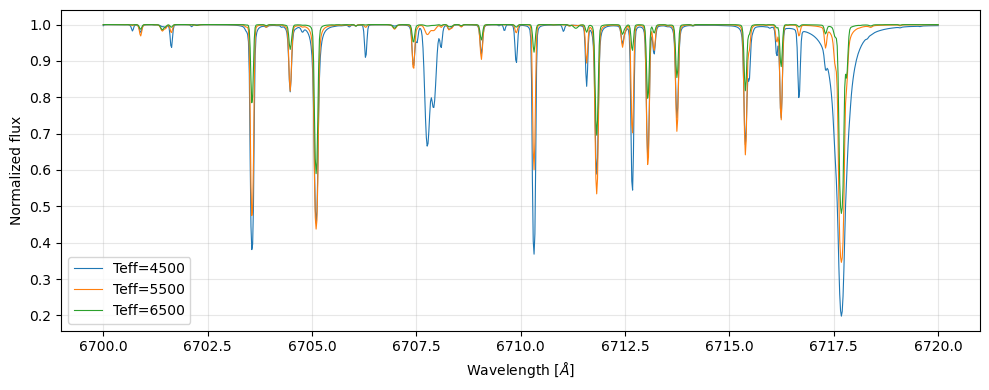

In [23]:
teffs = [4500, 5500, 6500]
lambda_window = dict(lambda_min=6700.0, lambda_max=6720.0, lambda_step=0.02)

spectra = {
    teff: synthesize_spectrum(teff=teff, logg=4.4, feh=0.0, vmicro=1.0,
                              **lambda_window, **DEFAULTS)
    for teff in teffs
}

fig, ax = plt.subplots(figsize=(10, 4))
for teff, spec in spectra.items():
    ax.plot(spec.wavelength, spec.flux_normalized, lw=0.8, label=f'Teff={teff}')
ax.set_xlabel(r'Wavelength [$\AA$]')
ax.set_ylabel('Normalized flux')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Custom abundances

Pass standard short-name keys (`a` = alpha, `c`, `n`, `o`, `r`, `s`) or element symbols. Values are dex offsets from solar.


--- Turbospectrum Configuration ---
project_root: /Users/mjablons/code/turbo
compiler: gf
nlte: False
nlte_info_file: 
force: True
model_atmosphere_path: /Users/mjablons/code/turbo/input_files/model_atmospheres/1D/marcs_standard_comp/marcs_standard_comp
linelist_path: /Users/mjablons/code/turbo/input_files/linelists
linelist_files: ['/Users/mjablons/code/turbo/input_files/linelists/nlte_ges_linelist_jmg16jan2026_I_II']
output_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_tutjjpux/spectra
log_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_tutjjpux/logs
tmp_dir: /var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/turbo_api_tutjjpux/tmp
babsma_exec: babsma_lu
bsyn_exec: bsyn_lu
interpol_exec: interpol_modeles
babsma_path: /Users/mjablons/code/turbo/exec-gf/babsma_lu
bsyn_path: /Users/mjablons/code/turbo/exec-gf/bsyn_lu
interpol_path: /Users/mjablons/code/turbo/interpolator/interpol_modeles
output_mode: Flux
mu_angles: []
mu_points_file: 
mu_sampling: {}
la

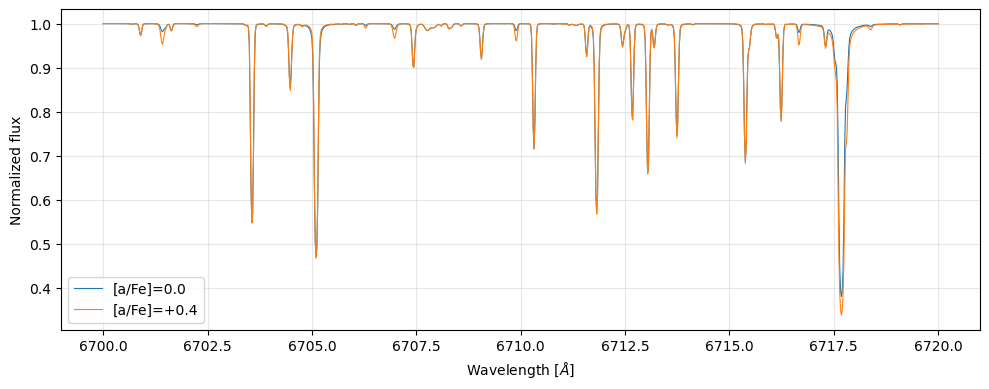

In [24]:
ref            = synthesize_spectrum(teff=5777, logg=4.4, feh=0.0, vmicro=1.0,
                                     lambda_min=6700.0, lambda_max=6720.0, lambda_step=0.02,
                                     **DEFAULTS)
alpha_enhanced = synthesize_spectrum(teff=5777, logg=4.4, feh=0.0, vmicro=1.0,
                                     abundances={'a': 0.4},
                                     lambda_min=6700.0, lambda_max=6720.0, lambda_step=0.02,
                                     **DEFAULTS)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ref.wavelength, ref.flux_normalized, lw=0.8, label='[a/Fe]=0.0')
ax.plot(alpha_enhanced.wavelength, alpha_enhanced.flux_normalized, lw=0.8, label='[a/Fe]=+0.4')
ax.set_xlabel(r'Wavelength [$\AA$]')
ax.set_ylabel('Normalized flux')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. NLTE comparison (optional)

Requires NLTE departure data. Toggle `nlte=True` and (optionally) point `nlte_info_file` at the right `SPECIES_LTE_NLTE.dat`.

In [25]:
# Uncomment when NLTE data is downloaded.
# common = dict(teff=5777, logg=4.4, feh=0.0, vmicro=1.0,
#               lambda_min=6700.0, lambda_max=6720.0, lambda_step=0.02, **DEFAULTS)
# lte  = synthesize_spectrum(**common, nlte=False)
# nlte = synthesize_spectrum(**common, nlte=True)
#
# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(lte.wavelength,  lte.flux_normalized,  lw=0.8, label='LTE')
# ax.plot(nlte.wavelength, nlte.flux_normalized, lw=0.8, label='NLTE')
# ax.set_xlabel(r'Wavelength [$\AA$]')
# ax.set_ylabel('Normalized flux')
# ax.legend(); ax.grid(alpha=0.3)
# plt.tight_layout(); plt.show()

## API reference

```python
synthesize_spectrum(
    teff, logg, feh,
    *,
    vmicro=1.0,                        # km/s, or label like '01'
    lambda_min=5000.0, lambda_max=5500.0, lambda_step=0.05,
    abundances=None,                   # {'a': 0.0, 'C': -0.2, ...}
    output_mode='Flux',                # or 'Intensity'
    mu_angles=None,                    # Intensity only; sets bsyn's MU-POINTS file (1-30 values in [0,1])
    nlte=False, nlte_info_file=None,
    model_atmosphere_path=None, linelist_path=None, linelist_files=None,
    compiler='gf',                     # 'gf' | 'intel' | 'ifx'
    project_root=None,
    work_dir=None, keep_files=False,   # keep .spec/.opac/log files
    force=True,
) -> SpectrumResult
```

`SpectrumResult` fields:

| Field | Shape | Notes |
|---|---|---|
| `wavelength` | `(n_wavelength,)` | Å |
| `flux` | `(n_wavelength,)` | disk-integrated absolute, erg/s/cm²/Å |
| `flux_normalized` | `(n_wavelength,)` | disk-integrated continuum-normalized, ∈ [0, 1] |
| `continuum` | `(n_wavelength,)` | reconstructed `flux / flux_normalized` |
| `mu_angles` | `(n_mu,)` *or* `None` | Intensity mode only |
| `intensity` | `(n_mu, n_wavelength)` *or* `None` | Intensity mode only, absolute |
| `intensity_normalized` | `(n_mu, n_wavelength)` *or* `None` | Intensity mode only, normalized |
| `params`, `output_mode`, `nlte`, `output_path`, `log_path`, `base_name` | — | metadata |
| `raw_columns` | `(n_wavelength, n_cols)` *or* `None` | full .spec table, Intensity mode |

Notes:
- Each call writes opacity/.spec/log files to a temp dir; pass `work_dir=...` and `keep_files=True` to inspect them. On failure the temp dir is preserved so the log path the error references is still readable.
- For production grids, keep using `pipeline_from_config.py` — this API is for ad-hoc validation, not throughput.